In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')
df = pd.read_csv('titanic_cleaned.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,HasCabin
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0


In [14]:
print(df.describe())
print(df['Survived'].value_counts())
print(df['Pclass'].value_counts())
print(df['Sex'].value_counts())
print(df['Embarked'].value_counts())

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  891.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.112424    0.523008   
std     257.353842    0.486592    0.836071   13.304424    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   21.500000    0.000000   
50%     446.000000    0.000000    3.000000   26.000000    0.000000   
75%     668.500000    1.000000    3.000000   36.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare    HasCabin  FamilySize  
count  891.000000  891.000000  891.000000  891.000000  
mean     0.381594   32.204208    0.228956    1.904602  
std      0.806057   49.693429    0.420397    1.613459  
min      0.000000    0.000000    0.000000    1.000000  
25%      0.000000    7.910400    0.000000    1.000000  
50%      0.000000   14.454200    

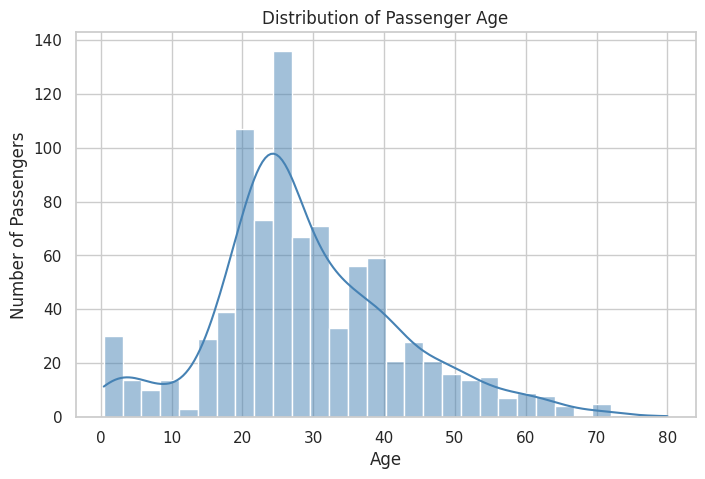

In [5]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Age'], bins=30, kde=True, color='steelblue')
plt.title('Distribution of Passenger Age')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.show()

/tmp/ipykernel_424/3595309283.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=df, palette='Set2')


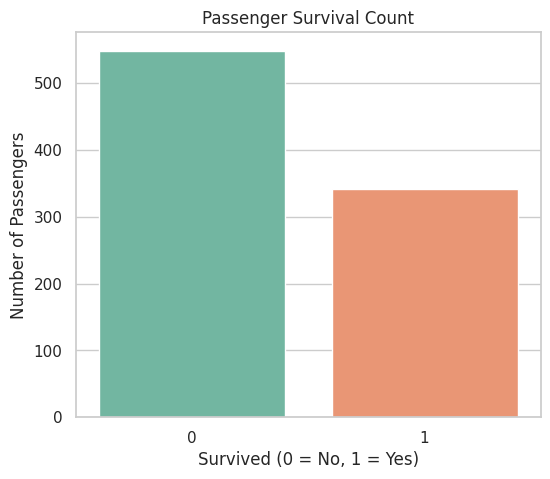

In [6]:
plt.figure(figsize=(6, 5))
sns.countplot(x='Survived', data=df, palette='Set2')
plt.title('Passenger Survival Count')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Number of Passengers')
plt.show()

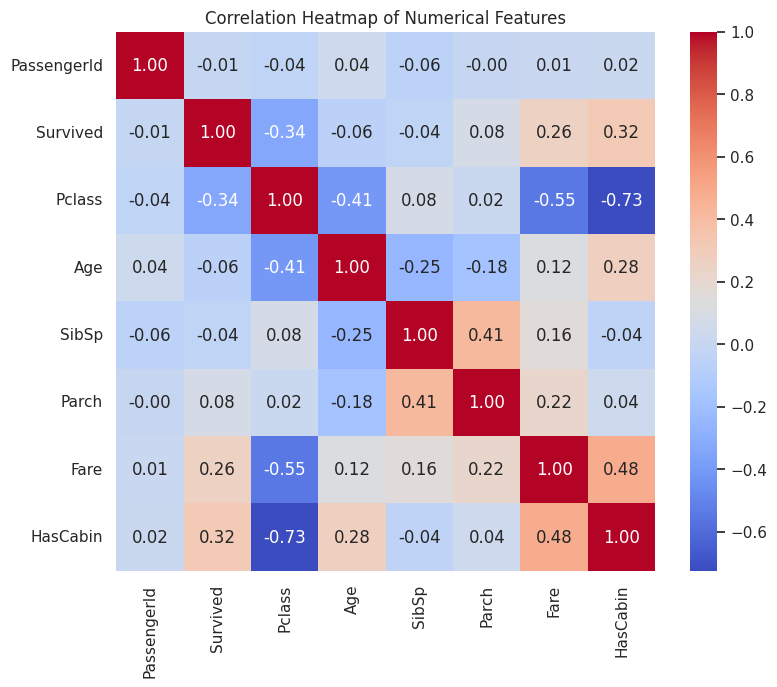

In [7]:
plt.figure(figsize=(9, 7))
numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

/tmp/ipykernel_424/2218571798.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Survived', y='Fare', data=df, palette='Set3')


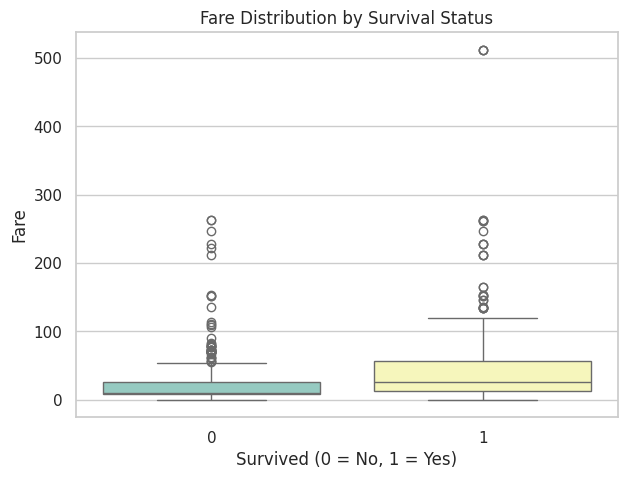

In [8]:
plt.figure(figsize=(7, 5))
sns.boxplot(x='Survived', y='Fare', data=df, palette='Set3')
plt.title('Fare Distribution by Survival Status')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Fare')
plt.show()

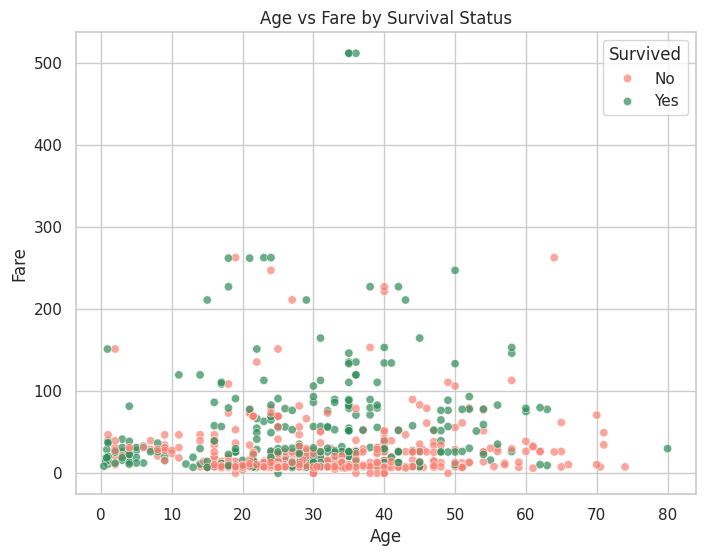

In [16]:
plt.figure(figsize=(8, 6))

df['Survival Status'] = df['Survived'].map({0: 'No', 1: 'Yes'})

sns.scatterplot(
    x='Age',
    y='Fare',
    hue='Survival Status',
    data=df,
    palette={'No': 'salmon', 'Yes': 'seagreen'},
    alpha=0.7
)

plt.title('Age vs Fare by Survival Status')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.legend(title='Survived')

plt.show()

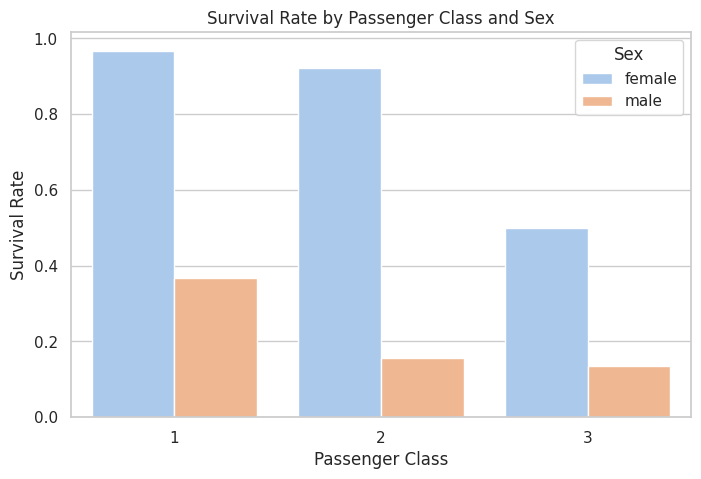

In [10]:
plt.figure(figsize=(8, 5))
sns.barplot(x='Pclass', y='Survived', hue='Sex', data=df,
            palette='pastel', errorbar=None)
plt.title('Survival Rate by Passenger Class and Sex')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.legend(title='Sex')
plt.show()

In [15]:
print(df.groupby('HasCabin')['Survived'].mean())
print(df.groupby('Pclass')['HasCabin'].mean())

HasCabin
0    0.299854
1    0.666667
Name: Survived, dtype: float64
Pclass
1    0.814815
2    0.086957
3    0.024440
Name: HasCabin, dtype: float64


In [12]:
bins = [0, 12, 19, 59, 100]
labels = ['Child', 'Teen', 'Adult', 'Senior']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)
df.groupby('AgeGroup', observed=True)['Survived'].mean()

,Survived
AgeGroup,
Child,0.579710
Teen,0.410526
Adult,0.365193
Senior,0.269231


In [13]:
df.groupby('HasCabin')['Survived'].mean()
df.groupby('Pclass')['HasCabin'].mean()

,HasCabin
Pclass,
1,0.814815
2,0.086957
3,0.024440
